# **Perbandingan Algoritma Logistic Regression, Random Forest, dan XGBoost untuk Klasifikasi Persetujuan Pinjaman Bank**

Nama  : Hamdika Putra

Nim   : 22.11.5220

Kelas : Proyek Data Mining 7

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [ ]:
# Membaca data dari file CSV yang terletak di URL github (menggunakan raw URL)
df = pd.read_csv('https://raw.githubusercontent.com/RazeYuki/Pinjaman/main/loan_data.csv')
df.head(10)

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1
5,21.0,female,High School,12951.0,0,OWN,2500.0,VENTURE,7.14,0.19,2.0,532,No,1
6,26.0,female,Bachelor,93471.0,1,RENT,35000.0,EDUCATION,12.42,0.37,3.0,701,No,1
7,24.0,female,High School,95550.0,5,RENT,35000.0,MEDICAL,11.11,0.37,4.0,585,No,1
8,24.0,female,Associate,100684.0,3,RENT,35000.0,PERSONAL,8.90,0.35,2.0,544,No,1
9,21.0,female,High School,12739.0,0,OWN,1600.0,VENTURE,14.74,0.13,3.0,640,No,1


In [ ]:
# Menampilkan data nama coloms
print(df.columns)

Index(['person_age', 'person_gender', 'person_education', 'person_income',
       'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_intent',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score', 'previous_loan_defaults_on_file', 'loan_status'],
      dtype='object')


In [ ]:
# Menampilkan type data pada setiap kolom
print(df.dtypes)

person_age                        float64
person_gender                      object
person_education                   object
person_income                     float64
person_emp_exp                      int64
person_home_ownership              object
loan_amnt                         float64
loan_intent                        object
loan_int_rate                     float64
loan_percent_income               float64
cb_person_cred_hist_length        float64
credit_score                        int64
previous_loan_defaults_on_file     object
loan_status                         int64
dtype: object


In [ ]:
# Mendapatkan dan menampilkan bentuk (dimensi) dari DataFrame (Jumlah Baris dan Kolom)
df.shape

(45000, 14)

In [ ]:
# Fungsi df.info() digunakan untuk mendapatkan informasi ringkas tentang DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [ ]:
# df.nunique() menghitung jumlah nilai unik dalam setiap kolom dari DataFrame
print(df.nunique())

person_age                           60
person_gender                         2
person_education                      5
person_income                     33989
person_emp_exp                       63
person_home_ownership                 4
loan_amnt                          4483
loan_intent                           6
loan_int_rate                      1302
loan_percent_income                  64
cb_person_cred_hist_length           29
credit_score                        340
previous_loan_defaults_on_file        2
loan_status                           2
dtype: int64


In [ ]:
  # Mencari Jumlah Sel yang Null
  df.isnull().sum()

,0
person_age,0
person_gender,0
person_education,0
person_income,0
person_emp_exp,0
person_home_ownership,0
loan_amnt,0
loan_intent,0
loan_int_rate,0
loan_percent_income,0


In [ ]:
print(df.duplicated().sum())

0


In [ ]:
print(df.describe())

         person_age  person_income  person_emp_exp     loan_amnt  \
count  45000.000000   4.500000e+04    45000.000000  45000.000000   
mean      27.764178   8.031905e+04        5.410333   9583.157556   
std        6.045108   8.042250e+04        6.063532   6314.886691   
min       20.000000   8.000000e+03        0.000000    500.000000   
25%       24.000000   4.720400e+04        1.000000   5000.000000   
50%       26.000000   6.704800e+04        4.000000   8000.000000   
75%       30.000000   9.578925e+04        8.000000  12237.250000   
max      144.000000   7.200766e+06      125.000000  35000.000000   

       loan_int_rate  loan_percent_income  cb_person_cred_hist_length  \
count   45000.000000         45000.000000                45000.000000   
mean       11.006606             0.139725                    5.867489   
std         2.978808             0.087212                    3.879702   
min         5.420000             0.000000                    2.000000   
25%         8.590000  

In [ ]:
# Memilih kolom-kolom bertipe kategorikal (tipe object/string)
cat_cols = df.select_dtypes(include=['object']).columns

# Memilih kolom-kolom bertipe numerik (int/float)
num_cols = df.select_dtypes(include=np.number).columns.tolist()

# Menampilkan hasil
print(cat_cols)
print(num_cols)


Index(['person_gender', 'person_education', 'person_home_ownership',
       'loan_intent', 'previous_loan_defaults_on_file'],
      dtype='object')
['person_age', 'person_income', 'person_emp_exp', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score', 'loan_status']


In [ ]:
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [ ]:
num_cols.remove('loan_status')
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

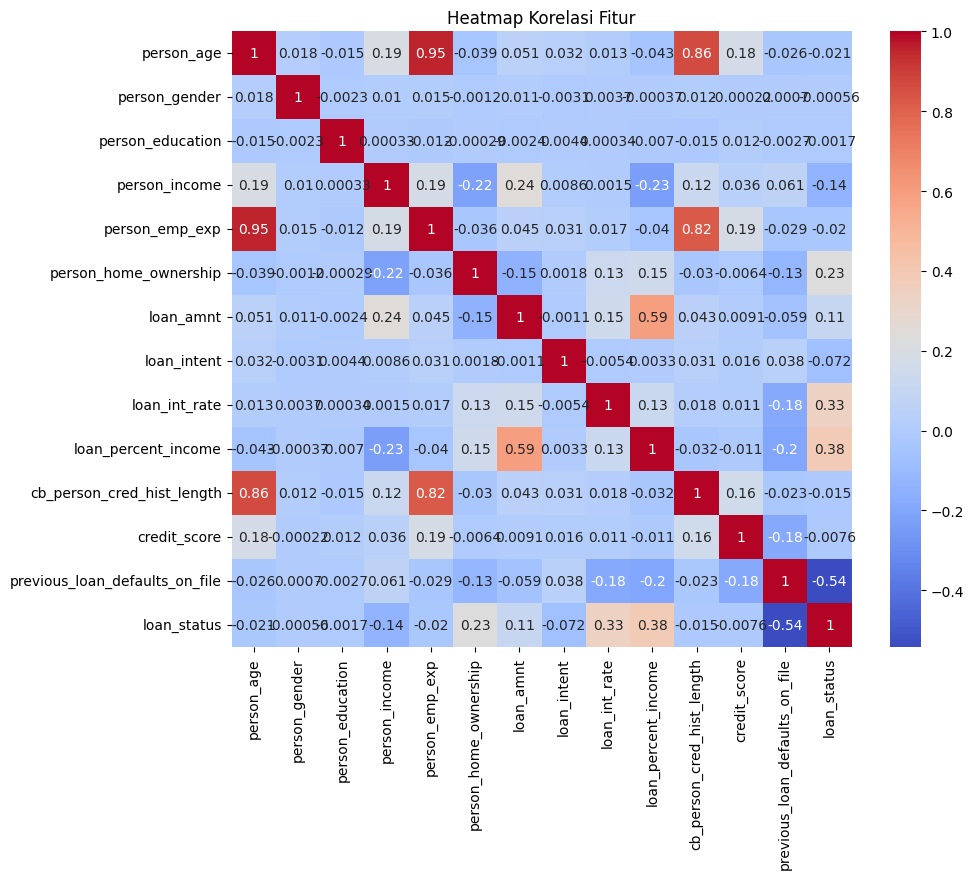

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Heatmap Korelasi Fitur')
plt.show()

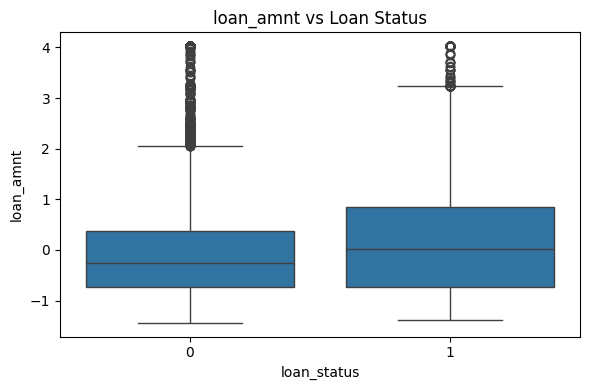

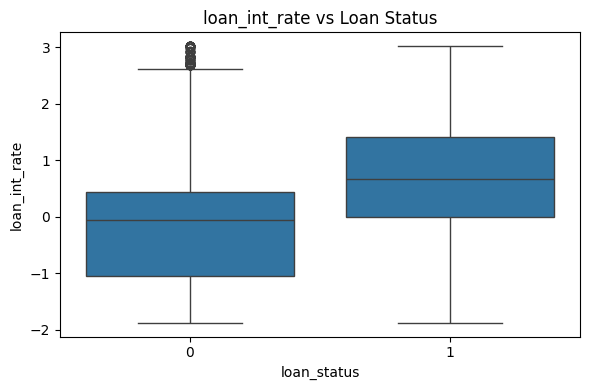

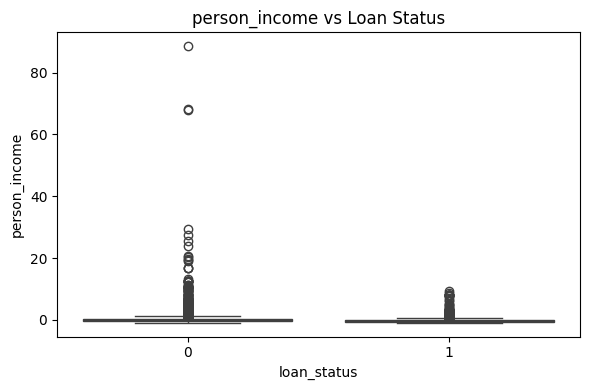

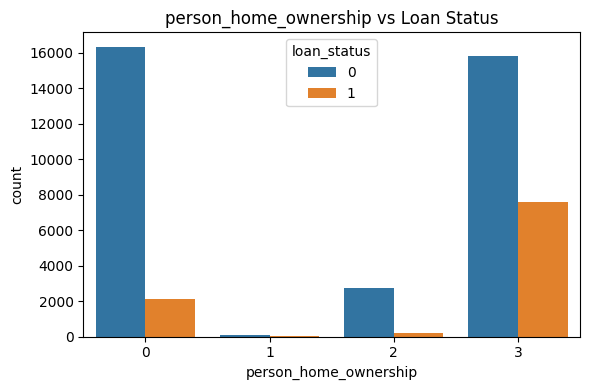

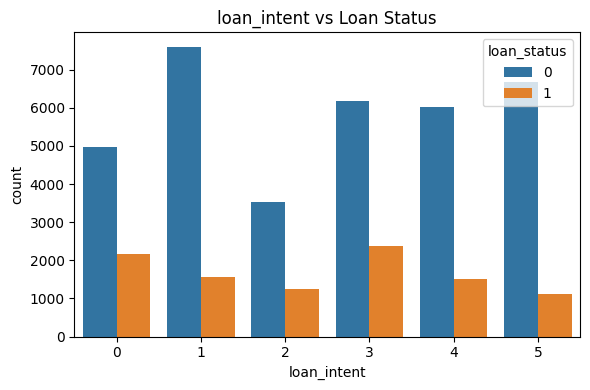

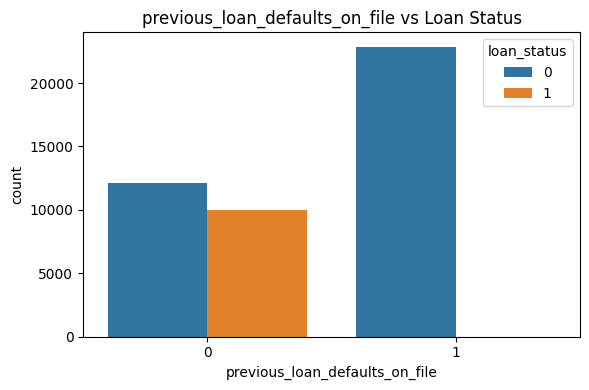

In [ ]:
selected_features = [
    'loan_amnt',
    'loan_int_rate',
    'person_income',
    'person_home_ownership',
    'loan_intent',
    'previous_loan_defaults_on_file'
]

for col in selected_features:
    plt.figure(figsize=(6, 4))
    if col in cat_cols:
        sns.countplot(x=col, hue='loan_status', data=df)
    else:
        sns.boxplot(x='loan_status', y=col, data=df)
    plt.title(f'{col} vs Loan Status')
    plt.tight_layout()
    plt.show()

In [ ]:
X = df[selected_features]
y = df['loan_status']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', LogisticRegression())
    ]),
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

results = {}

In [ ]:
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"\nModel: {name}")
    print("Accuracy:", acc)
    print(classification_report(y_test, y_pred))
    results[name] = acc


Model: Logistic Regression
Accuracy: 0.8746666666666667
              precision    recall  f1-score   support

           0       0.92      0.92      0.92      6990
           1       0.72      0.71      0.72      2010

    accuracy                           0.87      9000
   macro avg       0.82      0.82      0.82      9000
weighted avg       0.87      0.87      0.87      9000


Model: Random Forest
Accuracy: 0.9298888888888889
              precision    recall  f1-score   support

           0       0.94      0.97      0.96      6990
           1       0.88      0.80      0.84      2010

    accuracy                           0.93      9000
   macro avg       0.91      0.88      0.90      9000
weighted avg       0.93      0.93      0.93      9000


Model: XGBoost
Accuracy: 0.9286666666666666
              precision    recall  f1-score   support

           0       0.94      0.97      0.95      6990
           1       0.87      0.80      0.83      2010

    accuracy                 

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [13:08:57] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



Perbandingan Akurasi Model:
                     Accuracy
Random Forest        0.929889
XGBoost              0.928667
Logistic Regression  0.874667


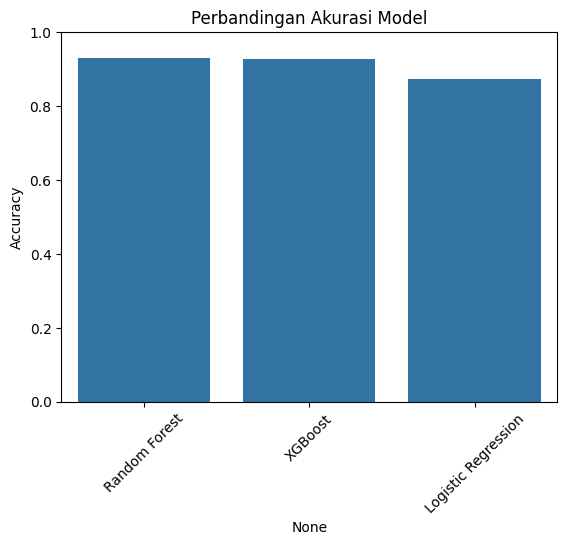

In [ ]:
result_df = pd.DataFrame.from_dict(results, orient='index', columns=['Accuracy'])
result_df = result_df.sort_values(by='Accuracy', ascending=False)
print("\nPerbandingan Akurasi Model:")
print(result_df)

sns.barplot(x=result_df.index, y='Accuracy', data=result_df)
plt.title('Perbandingan Akurasi Model')
plt.ylim(0, 1)
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
plt.show()

In [ ]:
best_model_name = result_df.idxmax().values[0]
best_model = models[best_model_name]